In [1]:
import cv2
import mediapipe as mp
import numpy as np
import os

mp_hands = mp.solutions.hands

DATA_DIR = r"C:\Users\Admin\Desktop\AIML sem 3\project\DataSets\Train"
SAVE_DIR = r"C:\Users\Admin\Desktop\AIML sem 3\project\DataSets\Features_video_1"

os.makedirs(SAVE_DIR, exist_ok=True)

actions = os.listdir(DATA_DIR)
print("Detected Classes:", actions)


def extract_hand_keypoints(results):
    
    
    left = []
    right = []

    if results.multi_hand_landmarks:

        for idx, hand_landmarks in enumerate(results.multi_hand_landmarks):
            label = results.multi_handedness[idx].classification[0].label

            keypoints = []
            for lm in hand_landmarks.landmark:
                keypoints.extend([lm.x, lm.y, lm.z])

            if label == "Left":
                left = keypoints
            else:
                right = keypoints

    # 👇 Change: If no hands detected → return None
    if len(left) == 0 and len(right) == 0:
        return None

    # Even if one hand missing, fill missing with 63 zeros
    if len(left) == 0:
        left = [0] * 63
    if len(right) == 0:
        right = [0] * 63

    return np.array(left + right)


def process_video(path):
    seq = []
    cap = cv2.VideoCapture(path)

    with mp_hands.Hands(
        static_image_mode=False,
        max_num_hands=2,
        model_complexity=1,
        min_detection_confidence=0.5,
        min_tracking_confidence=0.5
    ) as hands:

        while True:
            ret, frame = cap.read()
            if not ret:
                break

            img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = hands.process(img)

            keypoints = extract_hand_keypoints(results)

         
            if keypoints is not None:
                seq.append(keypoints)

    cap.release()
    return np.array(seq)


for action in actions:
    class_path = os.path.join(DATA_DIR, action)

    for video in os.listdir(class_path):
        video_path = os.path.join(class_path, video)

        print("Processing:", video_path)

        seq = process_video(video_path)

        save_name = f"{action}_{video}.npy"
        save_path = os.path.join(SAVE_DIR, save_name)

        np.save(save_path, seq)

print("\n Done! Frames with no hand are skipped successfully!")


Detected Classes: ['Beautiful', 'Good_Morning', 'Happy', 'Headache', 'Hello', 'Namaste']
Processing: C:\Users\Admin\Desktop\AIML sem 3\project\DataSets\Train\Beautiful\Beautiful_1.mp4
Processing: C:\Users\Admin\Desktop\AIML sem 3\project\DataSets\Train\Good_Morning\Good_Morning_1.mp4
Processing: C:\Users\Admin\Desktop\AIML sem 3\project\DataSets\Train\Happy\Happy_1.mp4
Processing: C:\Users\Admin\Desktop\AIML sem 3\project\DataSets\Train\Headache\Headache_1.mp4
Processing: C:\Users\Admin\Desktop\AIML sem 3\project\DataSets\Train\Hello\Hello_1.mp4
Processing: C:\Users\Admin\Desktop\AIML sem 3\project\DataSets\Train\Namaste\Namaste_1.mp4

 Done! Frames with no hand are skipped successfully!


In [16]:
data=np.load(r"C:\Users\Admin\Desktop\Sign_Language_Communicator\DataSets\Keypoints_Hands\Beautiful_Beautiful_1.mp4.npy")

In [15]:
import pandas as pd
df = pd.DataFrame(data,columns=[i+1 for i in range(126)])
df

,1,2,3,4,5,6,7,8,9,10,...,117,118,119,120,121,122,123,124,125,126
0,0.264609,0.598813,-1.300061e-07,0.287512,0.611874,-0.012651,0.297436,0.628686,-0.016238,0.302455,...,-0.007531,0.709502,0.654833,-0.007824,0.700072,0.663363,-0.004527,0.69126,0.668465,-0.001436
1,0.264956,0.596738,-1.445168e-07,0.289789,0.610087,-0.010164,0.298958,0.627343,-0.012155,0.303941,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
2,0.263474,0.596152,-1.465838e-07,0.288974,0.609161,-0.011622,0.297260,0.626005,-0.014894,0.300456,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
3,0.263229,0.596324,-1.471745e-07,0.287937,0.609267,-0.012633,0.296195,0.626032,-0.016235,0.300003,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
4,0.263119,0.595119,-1.370839e-07,0.288489,0.608451,-0.012171,0.296955,0.625701,-0.015193,0.300869,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
102,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
103,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
104,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000


In [17]:
import pandas as pd
df = pd.DataFrame(data,columns=[i+1 for i in range(126)])
df

,1,2,3,4,5,6,7,8,9,10,...,117,118,119,120,121,122,123,124,125,126
0,0.216064,0.783687,-2.027827e-07,0.253646,0.797341,-0.022037,0.266195,0.821098,-0.028051,0.269347,...,0.006689,0.732777,0.837770,0.004752,0.716095,0.834514,0.005992,0.709680,0.826837,0.007185
1,0.218565,0.783577,-2.318696e-07,0.256105,0.798352,-0.020148,0.267508,0.821847,-0.025751,0.269832,...,0.000541,0.737513,0.837554,-0.002527,0.720224,0.834744,-0.000774,0.711565,0.828082,0.001706
2,0.220553,0.782151,-2.353759e-07,0.258451,0.797827,-0.021052,0.270092,0.821546,-0.027420,0.271654,...,0.002834,0.742235,0.837378,0.000686,0.724659,0.834238,0.002617,0.715836,0.826664,0.005171
3,0.223426,0.781280,-2.410939e-07,0.262063,0.796865,-0.021734,0.273805,0.820568,-0.027416,0.274301,...,0.001793,0.746107,0.837340,-0.000687,0.728054,0.834651,0.000818,0.718457,0.827752,0.003237
4,0.227773,0.780819,-2.363362e-07,0.265913,0.796690,-0.021211,0.277389,0.820348,-0.027040,0.278392,...,0.002418,0.749949,0.837537,0.000709,0.731678,0.834590,0.002860,0.722435,0.827333,0.005671
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144,0.235270,0.766034,-1.089635e-07,0.271576,0.782985,0.006633,0.281710,0.804625,0.010678,0.274324,...,0.005398,0.803941,0.827784,0.009424,0.792959,0.823221,0.014839,0.790539,0.816196,0.018545
145,0.235959,0.766436,-1.087575e-07,0.271778,0.783828,0.006315,0.281819,0.805515,0.010137,0.274136,...,0.005036,0.805344,0.828119,0.009041,0.795156,0.822998,0.014826,0.793488,0.815680,0.018894
146,0.234607,0.766361,-1.200925e-07,0.270911,0.782933,0.007175,0.282205,0.804377,0.011952,0.275530,...,0.002893,0.805866,0.826906,0.007438,0.796129,0.821523,0.013986,0.795154,0.814223,0.018555
147,0.236725,0.766821,-1.086378e-07,0.272722,0.784421,0.007236,0.282553,0.805972,0.011479,0.274755,...,0.005213,0.807042,0.826916,0.011435,0.796907,0.822321,0.017890,0.794832,0.815285,0.022041


In [2]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence

In [3]:
class SignDataset(Dataset):
    def __init__(self, data_dir):
        self.data_dir = data_dir
        self.files = os.listdir(data_dir)

        self.classes = sorted(list(set([f.split("_")[0] for f in self.files])))
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file = self.files[idx]
        data = np.load(os.path.join(self.data_dir, file))

        class_name = file.split("_")[0]
        label = self.class_to_idx[class_name]

        return torch.tensor(data, dtype=torch.float32), torch.tensor(label)


In [4]:
def collate_fn(batch):
    sequences = [item[0] for item in batch]
    labels = torch.tensor([item[1] for item in batch])

    lengths = torch.tensor([len(seq) for seq in sequences])
    padded = pad_sequence(sequences, batch_first=True)

    return padded, lengths, labels


In [5]:
class BiLSTMModel(nn.Module):
    def __init__(self, input_dim=126, hidden_dim=128, num_classes=6):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=2,
            batch_first=True,
            bidirectional=True
        )

        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x, lengths):
        packed = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        output, (hn, cn) = self.lstm(packed)

        # last forward + last backward hidden state
        last_hidden = torch.cat((hn[-2], hn[-1]), dim=1)

        return self.fc(last_hidden)


In [8]:
TRAIN_PATH = r"C:\Users\Admin\Desktop\AIML sem 3\project\DataSets\Features_video_1"
VAL_PATH   = r"C:\Users\Admin\Desktop\AIML sem 3\project\DataSets\Keypoints_Hands_Validation"

train_dataset = SignDataset(TRAIN_PATH)
val_dataset   = SignDataset(VAL_PATH)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset, batch_size=4, shuffle=False, collate_fn=collate_fn)


In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BiLSTMModel(num_classes=len(train_dataset.classes)).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [10]:
epochs = 200
best_val_acc = 0

save_path = r"C:\Users\Admin\Desktop\AIML sem 3\project\Models\video_1.pth"

for epoch in range(1, epochs + 1):

    # -------------------- TRAINING --------------------
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for seq, lengths, labels in train_loader:
        seq = seq.to(device)
        lengths = lengths.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(seq, lengths)
        loss = criterion(outputs, labels)
        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()

        total_loss += loss.item()
        predicted = torch.argmax(outputs, dim=1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total * 100
    train_loss = total_loss


    # -------------------- VALIDATION --------------------
    model.eval()
    val_total_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for seq, lengths, labels in val_loader:
            seq = seq.to(device)
            lengths = lengths.to(device)
            labels = labels.to(device)

            outputs = model(seq, lengths)
            loss = criterion(outputs, labels)
            val_total_loss += loss.item()

            predicted = torch.argmax(outputs, dim=1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total * 100


    # -------------------- PRINT RESULTS --------------------
    print(f"Epoch {epoch}/{epochs} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_total_loss:.4f} | Val Acc: {val_acc:.2f}%")


    # -------------------- SAVE BEST MODEL --------------------
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), save_path)
        print(f"🔥 Best model saved! (Val Acc: {best_val_acc:.2f}%)")


print("\n🎉 Training Completed!")
print(f"Best Model Path: {save_path}")


Epoch 1/200 | Train Loss: 3.6933 | Train Acc: 0.00% | Val Loss: 8.9484 | Val Acc: 22.22%
🔥 Best model saved! (Val Acc: 22.22%)
Epoch 2/200 | Train Loss: 3.5347 | Train Acc: 33.33% | Val Loss: 8.8741 | Val Acc: 33.33%
🔥 Best model saved! (Val Acc: 33.33%)
Epoch 3/200 | Train Loss: 3.4919 | Train Acc: 50.00% | Val Loss: 8.7926 | Val Acc: 22.22%
Epoch 4/200 | Train Loss: 3.2726 | Train Acc: 66.67% | Val Loss: 8.7078 | Val Acc: 33.33%
Epoch 5/200 | Train Loss: 3.2070 | Train Acc: 50.00% | Val Loss: 8.6228 | Val Acc: 27.78%
Epoch 6/200 | Train Loss: 3.1127 | Train Acc: 50.00% | Val Loss: 8.6060 | Val Acc: 22.22%
Epoch 7/200 | Train Loss: 2.7509 | Train Acc: 66.67% | Val Loss: 8.6824 | Val Acc: 27.78%
Epoch 8/200 | Train Loss: 2.4272 | Train Acc: 50.00% | Val Loss: 8.9352 | Val Acc: 33.33%
Epoch 9/200 | Train Loss: 2.3197 | Train Acc: 50.00% | Val Loss: 9.4758 | Val Acc: 16.67%
Epoch 10/200 | Train Loss: 2.3514 | Train Acc: 50.00% | Val Loss: 9.9214 | Val Acc: 16.67%
Epoch 11/200 | Train Los

In [11]:
import cv2
import mediapipe as mp
import numpy as np
import torch
import torch.nn as nn
import os


class BiLSTMModel(nn.Module):
    def __init__(self, input_dim=126, hidden_dim=128, num_classes=6):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=2,
            batch_first=True,
            bidirectional=True
        )
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x, lengths):
        packed = torch.nn.utils.rnn.pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        output, (hn, cn) = self.lstm(packed)
        last_hidden = torch.cat((hn[-2], hn[-1]), dim=1)
        return self.fc(last_hidden)


mp_hands = mp.solutions.hands

def extract_hand_keypoints(results):
    left = []
    right = []

    if results.multi_hand_landmarks:
        for i, hand in enumerate(results.multi_hand_landmarks):
            label = results.multi_handedness[i].classification[0].label
            kp = []
            for lm in hand.landmark:
                kp.extend([lm.x, lm.y, lm.z])

            if label == "Left":
                left = kp
            else:
                right = kp

    # ---- NEW CHANGE: skip frame if no hands ----
    if len(left) == 0 and len(right) == 0:
        return None

    # ---- missing hand = fill zeros ----
    if len(left) == 0:
        left = [0] * 63
    if len(right) == 0:
        right = [0] * 63

    return np.array(left + right)


def video_to_keypoints(video_path):
    seq = []
    cap = cv2.VideoCapture(video_path)

    with mp_hands.Hands(
        max_num_hands=2,
        min_detection_confidence=0.2,
        min_tracking_confidence=0.2
    ) as hands:

        while True:
            ret, frame = cap.read()
            if not ret:
                break

            img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = hands.process(img)

            keypoints = extract_hand_keypoints(results)

            # ---- NEW CHANGE: only save if hand detected ----
            if keypoints is not None:
                seq.append(keypoints)

    cap.release()
    return np.array(seq)


MODEL_PATH = r"C:\Users\Admin\Desktop\AIML sem 3\project\Models\video_1.pth"

class_names = ["Beautiful", "Good_Morning", "Happy", "Headache", "Hello", "Namaste"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = BiLSTMModel(num_classes=len(class_names))
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.to(device)
model.eval()


def predict(seq):
    if len(seq) == 0:
        return "No Hands Detected", 0.0

    t = torch.tensor(seq, dtype=torch.float32).unsqueeze(0).to(device)
    length = torch.tensor([len(seq)]).to(device)

    with torch.no_grad():
        out = model(t, length)
        idx = torch.argmax(out, dim=1).item()
        conf = torch.softmax(out, dim=1)[0][idx].item()

    return class_names[idx], conf


TEST_DIR = r"C:\Users\Admin\Desktop\AIML sem 3\project\DataSets\person\person1"

print("--------- TEST PREDICTIONS ---------\n")

for video in os.listdir(TEST_DIR):
    video_path = os.path.join(TEST_DIR, video)

    if not video.lower().endswith((".mp4", ".avi", ".mov", ".mkv")):
        continue

    print(f"Processing: {video}")

    seq = video_to_keypoints(video_path)
    print("Sequence Shape:", seq.shape)

    label, conf = predict(seq)
    print(f"> Prediction: {label} | Confidence: {conf:.2f}\n")

print("✔ Testing Completed!")


--------- TEST PREDICTIONS ---------

Processing: Person1_Beautiful.mp4
Sequence Shape: (135, 126)
> Prediction: Happy | Confidence: 0.77

Processing: Person1_GoodMorning.mp4
Sequence Shape: (115, 126)
> Prediction: Happy | Confidence: 0.79

Processing: Person1_Happy.mp4
Sequence Shape: (78, 126)
> Prediction: Happy | Confidence: 0.83

Processing: Person1_Headache.mp4
Sequence Shape: (115, 126)
> Prediction: Happy | Confidence: 0.72

Processing: Person1_Hello.mp4
Sequence Shape: (87, 126)
> Prediction: Happy | Confidence: 0.62

Processing: Person1_Namaste.mp4
Sequence Shape: (105, 126)
> Prediction: Happy | Confidence: 0.77

✔ Testing Completed!


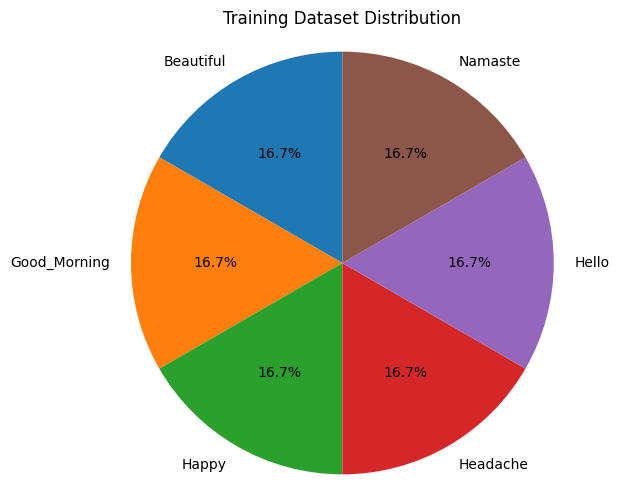

In [4]:
import matplotlib.pyplot as plt

# Class names
classes = ['Beautiful', 'Good_Morning', 'Happy', 'Headache', 'Hello', 'Namaste']

# Number of videos per class
videos = [15, 15, 15, 15, 15, 15]

# Create pie chart
plt.figure(figsize=(6, 6))
plt.pie(videos, labels=classes, autopct='%1.1f%%', startangle=90)
plt.title('Training Dataset Distribution')

# Equal aspect ratio ensures pie is circular
plt.axis('equal')

plt.show()


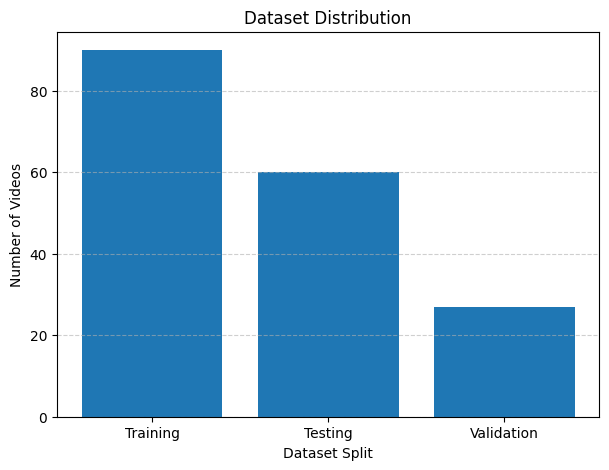

In [5]:

import matplotlib.pyplot as plt


datasets = ['Training', 'Testing', 'Validation']
videos = [90, 60, 27]

plt.figure(figsize=(7, 5))
plt.bar(datasets, videos)

plt.title('Dataset Distribution')
plt.xlabel('Dataset Split')
plt.ylabel('Number of Videos')

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()


--------- TEST PREDICTIONS ---------

Processing: Person8_Beautiful.mp4
Sequence Shape: (135, 126)
> Actual    : Beautiful
> Predicted : Beautiful | Confidence: 0.70

Processing: Person8_Good_Morning.mp4
Sequence Shape: (112, 126)
> Actual    : Good_Morning
> Predicted : Good_Morning | Confidence: 0.96

Processing: Person8_Happy.mp4
Sequence Shape: (103, 126)
> Actual    : Happy
> Predicted : Namaste | Confidence: 0.96

Processing: Person8_Headache.mp4
Sequence Shape: (108, 126)
> Actual    : Headache
> Predicted : Headache | Confidence: 0.87

Processing: Person8_Hello.mp4
Sequence Shape: (104, 126)
> Actual    : Hello
> Predicted : Hello | Confidence: 0.92

Processing: Person8_Namaste.mp4
Sequence Shape: (104, 126)
> Actual    : Namaste
> Predicted : Namaste | Confidence: 0.99

✔ Testing Completed!

========= CONFUSION MATRIX =========
[[1 0 0 0 0 0]
 [0 1 0 0 0 0]
 [0 0 0 0 0 1]
 [0 0 0 1 0 0]
 [0 0 0 0 1 0]
 [0 0 0 0 0 1]]


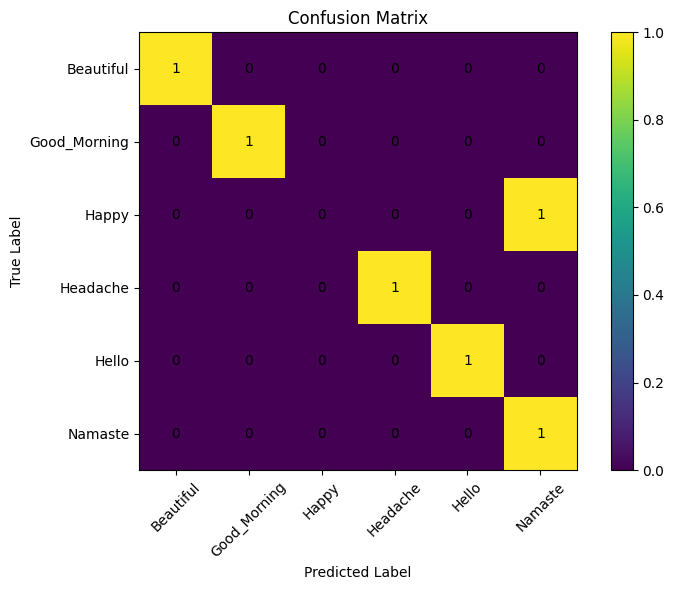


===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

   Beautiful       1.00      1.00      1.00         1
Good_Morning       1.00      1.00      1.00         1
       Happy       0.00      0.00      0.00         1
    Headache       1.00      1.00      1.00         1
       Hello       1.00      1.00      1.00         1
     Namaste       0.50      1.00      0.67         1

    accuracy                           0.83         6
   macro avg       0.75      0.83      0.78         6
weighted avg       0.75      0.83      0.78         6



C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classificati

In [6]:
import cv2
import mediapipe as mp
import numpy as np
import torch
import torch.nn as nn
import os
import matplotlib.pyplot as plt


from sklearn.metrics import confusion_matrix, classification_report

# -----------------------
# 1) MODEL CLASS
# -----------------------
class BiLSTMModel(nn.Module):
    def __init__(self, input_dim=126, hidden_dim=128, num_classes=6):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=2,
            batch_first=True,
            bidirectional=True
        )
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x, lengths):
        packed = torch.nn.utils.rnn.pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        output, (hn, cn) = self.lstm(packed)
        last_hidden = torch.cat((hn[-2], hn[-1]), dim=1)
        return self.fc(last_hidden)


# -----------------------
# 2) HAND LANDMARK EXTRACTOR
# -----------------------
mp_hands = mp.solutions.hands

def extract_hand_keypoints(results):
    left = []
    right = []

    if results.multi_hand_landmarks:
        for i, hand in enumerate(results.multi_hand_landmarks):
            label = results.multi_handedness[i].classification[0].label
            kp = []
            for lm in hand.landmark:
                kp.extend([lm.x, lm.y, lm.z])

            if label == "Left":
                left = kp
            else:
                right = kp

    if len(left) == 0 and len(right) == 0:
        return None

    if len(left) == 0:
        left = [0] * 63
    if len(right) == 0:
        right = [0] * 63

    return np.array(left + right)


def video_to_keypoints(video_path):
    seq = []
    cap = cv2.VideoCapture(video_path)

    with mp_hands.Hands(
        max_num_hands=2,
        min_detection_confidence=0.2,
        min_tracking_confidence=0.2
    ) as hands:

        while True:
            ret, frame = cap.read()
            if not ret:
                break

            img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = hands.process(img)

            keypoints = extract_hand_keypoints(results)
            if keypoints is not None:
                seq.append(keypoints)

    cap.release()
    return np.array(seq)


# -----------------------
# 3) LOAD MODEL
# -----------------------
MODEL_PATH = r"C:\Users\Admin\Desktop\Sign_Language_Communicator\Models\sign_bilstm_model_best.pth"

class_names = ["Beautiful", "Good_Morning", "Happy", "Headache", "Hello", "Namaste"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = BiLSTMModel(num_classes=len(class_names))
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.to(device)
model.eval()


# -----------------------
# 4) PREDICTION FUNCTION
# -----------------------
def predict(seq):
    if len(seq) == 0:
        return "No Hands Detected", 0.0

    t = torch.tensor(seq, dtype=torch.float32).unsqueeze(0).to(device)
    length = torch.tensor([len(seq)]).to(device)

    with torch.no_grad():
        out = model(t, length)
        idx = torch.argmax(out, dim=1).item()
        conf = torch.softmax(out, dim=1)[0][idx].item()

    return class_names[idx], conf


# -----------------------
# 5) READ ALL VIDEOS, PREDICT & COLLECT LABELS
# -----------------------
TEST_DIR = r"C:\Users\Admin\Desktop\Sign_Language_Communicator\DataSets\person\Person8"

y_true = []
y_pred = []

print("--------- TEST PREDICTIONS ---------\n")

for video in os.listdir(TEST_DIR):
    video_path = os.path.join(TEST_DIR, video)

    if not video.lower().endswith((".mp4", ".avi", ".mov", ".mkv")):
        continue

    print(f"Processing: {video}")

    # ---- TRUE LABEL FROM FILENAME ----
    # Example: Person1_Beautiful.mp4 → Beautiful
    name = os.path.splitext(video)[0]
    true_label_name = name.split("_", 1)[1]

    if true_label_name not in class_names:
        print("⚠ Unknown class, skipping\n")
        continue

    true_label = class_names.index(true_label_name)

    seq = video_to_keypoints(video_path)
    print("Sequence Shape:", seq.shape)

    pred_label_name, conf = predict(seq)
    pred_label = class_names.index(pred_label_name)

    y_true.append(true_label)
    y_pred.append(pred_label)

    print(f"> Actual    : {true_label_name}")
    print(f"> Predicted : {pred_label_name} | Confidence: {conf:.2f}\n")

print("✔ Testing Completed!")


print("\n========= CONFUSION MATRIX =========")
cm = confusion_matrix(y_true, y_pred)
print(cm)

# -----------------------
# 7) CONFUSION MATRIX VISUALIZATION
# -----------------------
plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks(range(len(class_names)), class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# numbers inside boxes
for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center")

plt.tight_layout()
plt.show()


print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))


In [54]:
import cv2
import mediapipe as mp
import numpy as np
import torch
import torch.nn as nn
import time

# ---------------------------------------------------
# 1) BiLSTM MODEL
# ---------------------------------------------------
class biLSTMModel(nn.Module):
    def __init__(self, input_dim=126, hidden_dim=128, num_classes=6):
        super().__init__()
        self.lstm = nn.LSTM(
            input_dim, hidden_dim,
            num_layers=2, batch_first=True, bidirectional=True
        )
        self.fc = nn.Linear(hidden_dim*2, num_classes)

    def forward(self, x, lengths):
        packed = torch.nn.utils.rnn.pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        _, (hn, _) = self.lstm(packed)
        last_hidden = torch.cat((hn[-2], hn[-1]), dim=1)
        return self.fc(last_hidden)

# ---------------------------------------------------
# 2) LOAD MODEL
# ---------------------------------------------------
MODEL_PATH = r"C:\Users\Admin\Desktop\Sign_Language_Communicator\Models\sign_bilstm_model_best.pth"
class_names = ["Beautiful", "Good_Morning", "Happy", "Headache", "Hello", "Namaste"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = BiLSTMModel(num_classes=len(class_names))
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.to(device)
model.eval()

# ---------------------------------------------------
# 3) MEDIAPIPE
# ---------------------------------------------------
mp_hands = mp.solutions.hands
mp_draw = mp.solutions.drawing_utils

def extract_keypoints(results):
    left = []
    right = []

    if results.multi_hand_landmarks:
        for i, hand in enumerate(results.multi_hand_landmarks):
            label = results.multi_handedness[i].classification[0].label
            pts = []
            for lm in hand.landmark:
                pts.extend([lm.x, lm.y, lm.z])
            if label == "Left":
                left = pts
            else:
                right = pts

    # ❌ NO HAND → return None → frame skip
    if len(left) == 0 and len(right) == 0:
        return None

    # Missing hand → fill zeros
    if len(left) == 0:
        left = [0]*63
    if len(right) == 0:
        right = [0]*63

    return np.array(left + right)

# ---------------------------------------------------
# 4) WEBCAM LOOP
# ---------------------------------------------------
cap = cv2.VideoCapture(0)
recording = False
seq_buffer = []

print("🟡 Press 'S' = Start Recording | 'Q' = Stop & Predict | 'V' = Quit Webcam")

with mp_hands.Hands(max_num_hands=2,
                    min_detection_confidence=0.5,
                    min_tracking_confidence=0.5) as hands:

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        key = cv2.waitKey(1) & 0xFF

        # QUIT
        if key == ord('v'):
            print("🔴 Force Quit (V)")
            cap.release()
            cv2.destroyAllWindows()
            exit()

        # START RECORDING
        if key == ord('s') and not recording:
            print("🟢 Recording Started...")
            recording = True
            seq_buffer = []

        # STOP RECORDING
        if key == ord('q') and recording:
            print("🛑 Recording Stopped!")
            break

        # Mediapipe Detection
        img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = hands.process(img_rgb)

        # Draw Hands
        if results.multi_hand_landmarks:
            for handLms in results.multi_hand_landmarks:
                mp_draw.draw_landmarks(frame, handLms, mp_hands.HAND_CONNECTIONS)

        # RECORDING MODE
        if recording:
            keypoints = extract_keypoints(results)

            if keypoints is not None:       # ← 👈 NEW CONDITION  
                seq_buffer.append(keypoints)

            cv2.putText(frame, "Recording...", (20,40),
                        cv2.FONT_HERSHEY_SIMPLEX, 1, (0,0,255), 2)
        else:
            cv2.putText(frame, "Press 'S' to Start Recording", (20,40),
                        cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,0), 2)

        cv2.imshow("Sign Recorder", frame)

cap.release()
cv2.destroyAllWindows()

# ---------------------------------------------------
# 5) FINAL PREDICTION
# ---------------------------------------------------
if len(seq_buffer) == 0:
    print("❌ No valid frames recorded (no hands detected).")
else:
    seq = np.array(seq_buffer)
    t = torch.tensor(seq, dtype=torch.float32).unsqueeze(0).to(device)
    length = torch.tensor([len(seq)]).to(device)

    with torch.no_grad():
        out = model(t, length)
        idx = torch.argmax(out, dim=1).item()
        conf = torch.softmax(out, dim=1)[0][idx].item()

    print("\n✨ You Performed Action:", class_names[idx])
    print("Confidence:", round(conf, 2))


🟡 Press 'S' = Start Recording | 'Q' = Stop & Predict | 'V' = Quit Webcam
🟢 Recording Started...
🛑 Recording Stopped!

✨ You Performed Action: Good_Morning
Confidence: 0.85


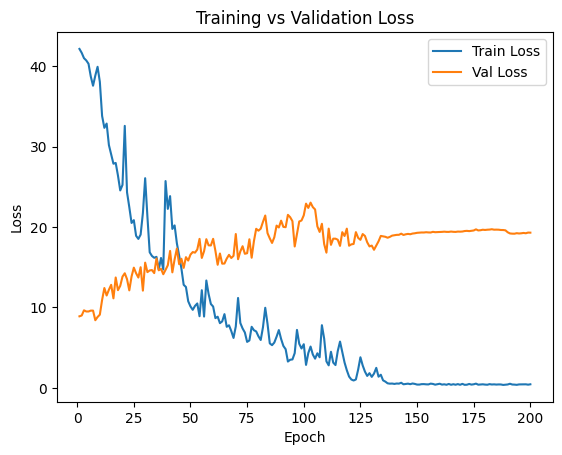

ValueError: x and y must have same first dimension, but have shapes (200,) and (190,)

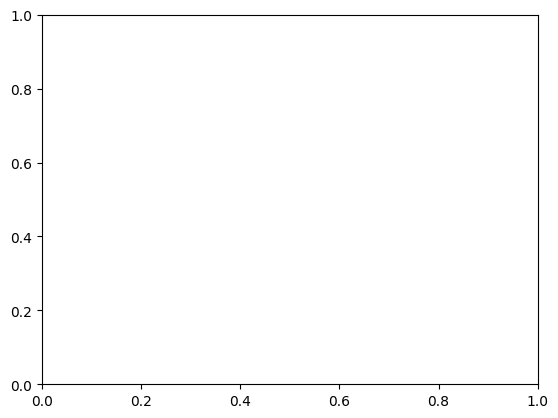

In [2]:
import matplotlib.pyplot as plt

# Epochs
epochs = list(range(1, 201))

# Train Loss
train_loss = [
42.1778,41.6878,41.0276,40.7475,40.3313,38.7494,37.5972,38.8611,39.9551,38.0788,
33.8316,32.3568,32.8879,30.2128,29.0607,27.8926,27.9891,26.4145,24.5676,25.2599,
32.6025,24.3338,22.4854,20.5187,20.8682,18.9209,18.5338,19.0717,21.7532,26.0900,
21.2870,16.8701,16.4113,16.1859,16.3028,14.7224,16.1653,14.7239,25.7336,22.2720,
23.8578,19.7757,20.2155,17.9806,16.4553,14.8428,12.8250,12.5482,10.7770,10.1320,
9.7083,10.1977,10.5023,8.9136,12.1505,8.8714,13.3580,11.6814,10.4333,10.1195,
8.6772,8.8552,8.0494,8.2685,9.1736,7.5988,7.7860,7.0740,6.2112,7.6442,
11.1853,8.0705,7.3905,6.8887,5.7204,5.8955,7.5970,7.1722,7.0185,6.4120,
5.9547,7.5550,9.9643,7.9698,5.5365,5.3110,5.6360,6.3638,7.1903,6.0836,
5.2153,4.8092,3.2721,3.4972,3.5358,4.3208,7.2100,5.4843,4.8995,5.4299,
2.8576,4.3275,5.1382,4.1478,3.6317,4.3023,3.8030,7.7974,6.1281,3.2974,
2.8002,4.4919,3.1381,2.8352,4.5784,5.7576,4.4761,3.1522,2.1887,1.4015,
1.0371,0.9144,1.0419,2.2725,3.8057,2.7901,2.0203,1.4838,1.8273,1.3672,
1.7716,2.4887,1.3904,1.6296,0.9312,0.7758,0.5630,0.5205,0.5354,0.4881,
0.5389,0.5240,0.6319,0.4433,0.4884,0.5221,0.4578,0.5419,0.4897,0.4084,
0.4058,0.4601,0.4655,0.4371,0.4267,0.5251,0.4861,0.3957,0.4594,0.5114,
0.4045,0.4407,0.3834,0.4842,0.3831,0.4511,0.3883,0.4653,0.3815,0.4953,
0.3766,0.3900,0.4845,0.4038,0.4445,0.5234,0.3940,0.4221,0.4407,0.4060,
0.3866,0.4612,0.4162,0.4347,0.4072,0.4259,0.4208,0.3640,0.3857,0.4191,
0.5099,0.4151,0.4034,0.3746,0.4272,0.4314,0.4404,0.4387,0.3958,0.4421
]

# Validation Loss
val_loss = [
8.9026,9.0045,9.6474,9.5043,9.5023,9.6115,9.6113,8.4143,8.8183,9.1079,
10.9446,12.4217,11.4922,12.2123,12.8194,11.1398,13.7335,12.1552,12.6962,13.8407,
14.2604,13.5236,12.1277,13.8596,14.9573,14.2608,13.7266,15.0089,12.0982,15.5799,
14.3995,14.6116,14.6549,14.2800,16.1026,14.6285,14.8124,14.1383,14.6824,15.2566,
17.0396,14.3739,15.9978,17.3362,15.3870,16.0638,14.9273,16.2638,15.8394,16.5836,
16.8966,16.8257,17.2108,18.5383,16.1671,17.0126,18.5015,17.7365,17.7178,18.5447,
17.0610,15.3127,16.7217,15.4523,15.4708,16.0839,16.5505,16.1576,16.4298,19.1439,
16.0050,16.9775,17.6250,16.6854,16.7532,18.4897,16.1932,18.2596,19.7928,19.5586,
19.8074,20.6620,21.4462,19.2537,18.6001,18.0326,18.7361,20.1894,19.9577,20.8056,
20.0295,19.9931,21.5303,21.2351,20.7398,17.5930,19.1277,20.7041,20.8247,21.4708,
22.9229,22.3902,23.0503,22.4884,22.1999,20.1019,19.4029,20.4180,17.8998,16.8241,
19.8141,17.7951,18.5648,18.5634,18.4334,17.6661,19.3729,18.8978,19.8127,17.6870,
17.8567,17.9069,19.3786,18.6652,18.4211,19.1378,18.9002,18.1115,17.6010,17.7035,
17.1805,17.7217,18.2374,18.9064,18.8478,18.7983,18.6810,18.7893,18.9445,18.9945,
19.0380,19.0455,19.1883,19.0266,19.1084,19.1585,19.1159,19.2014,19.2351,19.2923,
19.3104,19.3352,19.3318,19.3661,19.3418,19.3315,19.4145,19.3692,19.3813,19.3872,
19.4102,19.4352,19.4096,19.4077,19.4482,19.4170,19.4052,19.4468,19.4357,19.4539,
19.5149,19.5363,19.5041,19.5498,19.5837,19.7260,19.5895,19.6154,19.6765,19.6481,
19.6790,19.6949,19.7386,19.6815,19.6894,19.6810,19.6440,19.6404,19.6018,19.3601,
19.2147,19.1881,19.1826,19.2472,19.2094,19.2346,19.2778,19.2381,19.3224,19.3123
]

# Train Accuracy
train_acc = [
13.48,15.73,15.73,22.47,23.60,31.46,34.83,34.83,26.97,28.09,
39.33,37.08,32.58,48.31,49.44,44.94,46.07,47.19,56.18,55.06,
51.69,60.67,58.43,60.67,64.04,62.92,64.04,66.29,59.55,56.18,
57.30,67.42,62.92,69.66,66.29,67.42,70.79,71.91,64.04,57.30,
53.93,59.55,61.80,67.42,68.54,64.04,76.40,75.28,75.28,82.02,
80.90,83.15,77.53,80.90,78.65,83.15,77.53,73.03,78.65,82.02,
82.02,80.90,84.27,84.27,79.78,86.52,83.15,83.15,86.52,84.27,
80.90,80.90,85.39,84.27,88.76,86.52,79.78,89.89,85.39,87.64,
88.76,85.39,79.78,85.39,91.01,89.89,89.89,88.76,86.52,91.01,
92.13,91.01,96.63,93.26,93.26,89.89,84.27,86.52,91.01,91.01,
94.38,93.26,89.89,93.26,92.13,94.38,93.26,85.39,88.76,93.26,
93.26,92.13,95.51,93.26,91.01,88.76,92.13,92.13,94.38,97.75,
97.75,98.88,98.88,95.51,91.01,95.51,95.51,96.63,95.51,97.75,
96.63,95.51,96.63,94.38,97.75,97.75,98.88,98.88,97.75,97.75,
98.88,98.88,97.75,98.88,98.88,97.75,98.88,97.75,98.88,97.75,
97.75,97.75,98.88,97.75,98.88,97.75,97.75,97.75,98.88,98.88,
98.88,98.88,98.88,97.75,98.88,98.88,97.75,98.88,98.88,97.75,
98.88,98.88,98.88,98.88,98.88,98.88,98.88,97.75,98.88,98.88,
98.88,98.88,98.88,98.88,98.88,98.88,98.88,98.88,98.88,98.88
]

# Validation Accuracy
val_acc = [
16.67,16.67,16.67,27.78,22.22,33.33,27.78,27.78,27.78,22.22,
11.11,16.67,27.78,22.22,38.89,22.22,33.33,27.78,33.33,33.33,
27.78,22.22,38.89,38.89,33.33,33.33,33.33,27.78,27.78,27.78,
27.78,27.78,27.78,33.33,27.78,33.33,22.22,27.78,27.78,27.78,
22.22,27.78,33.33,27.78,38.89,27.78,27.78,33.33,38.89,38.89,
33.33,33.33,33.33,27.78,27.78,27.78,27.78,33.33,33.33,38.89,
38.89,38.89,38.89,38.89,38.89,38.89,38.89,38.89,38.89,27.78,
38.89,38.89,33.33,38.89,27.78,33.33,33.33,33.33,27.78,27.78,
33.33,33.33,27.78,27.78,38.89,38.89,27.78,27.78,38.89,33.33,
33.33,44.44,27.78,38.89,27.78,38.89,33.33,38.89,27.78,33.33,
22.22,27.78,22.22,16.67,27.78,27.78,27.78,11.11,22.22,11.11,
16.67,38.89,22.22,27.78,22.22,22.22,22.22,16.67,11.11,27.78,
33.33,33.33,27.78,22.22,27.78,16.67,22.22,22.22,22.22,22.22,
33.33,33.33,22.22,22.22,27.78,27.78,27.78,27.78,27.78,27.78,
27.78,27.78,27.78,27.78,27.78,27.78,27.78,27.78,27.78,27.78,
27.78,27.78,27.78,27.78,27.78,27.78,27.78,27.78,27.78,27.78,
27.78,27.78,27.78,27.78,27.78,27.78,27.78,27.78,33.33,33.33,
27.78,27.78,27.78,27.78,27.78,27.78,27.78,27.78,27.78,27.78,
27.78,27.78,27.78,27.78,27.78,27.78,27.78,27.78,27.78,27.78
]

epochs_loss = list(range(1, len(train_loss) + 1))
epochs_acc  = list(range(1, len(train_acc) + 1))

# -------- Plot Loss --------
plt.figure()
plt.plot(epochs, train_loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

# -------- Plot Accuracy --------
plt.figure()
plt.plot(epochs, train_acc, label="Train Accuracy")
plt.plot(epochs, val_acc, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()


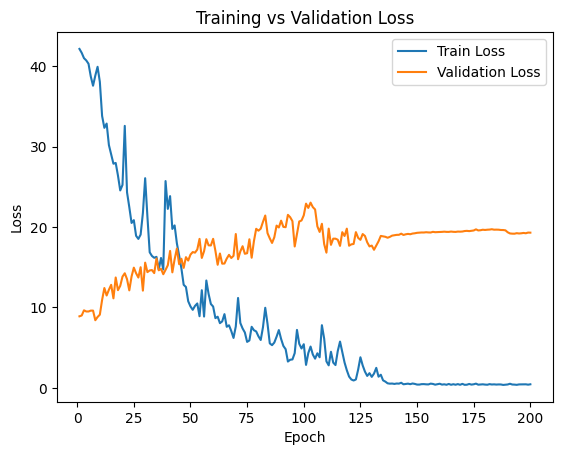

ValueError: x and y must have same first dimension, but have shapes (180,) and (190,)

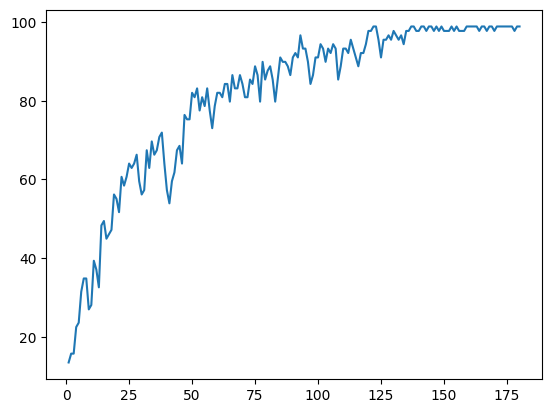

In [3]:
import matplotlib.pyplot as plt

# ===================== TRAIN LOSS =====================
train_loss = [
42.1778,41.6878,41.0276,40.7475,40.3313,38.7494,37.5972,38.8611,39.9551,38.0788,
33.8316,32.3568,32.8879,30.2128,29.0607,27.8926,27.9891,26.4145,24.5676,25.2599,
32.6025,24.3338,22.4854,20.5187,20.8682,18.9209,18.5338,19.0717,21.7532,26.0900,
21.2870,16.8701,16.4113,16.1859,16.3028,14.7224,16.1653,14.7239,25.7336,22.2720,
23.8578,19.7757,20.2155,17.9806,16.4553,14.8428,12.8250,12.5482,10.7770,10.1320,
9.7083,10.1977,10.5023,8.9136,12.1505,8.8714,13.3580,11.6814,10.4333,10.1195,
8.6772,8.8552,8.0494,8.2685,9.1736,7.5988,7.7860,7.0740,6.2112,7.6442,
11.1853,8.0705,7.3905,6.8887,5.7204,5.8955,7.5970,7.1722,7.0185,6.4120,
5.9547,7.5550,9.9643,7.9698,5.5365,5.3110,5.6360,6.3638,7.1903,6.0836,
5.2153,4.8092,3.2721,3.4972,3.5358,4.3208,7.2100,5.4843,4.8995,5.4299,
2.8576,4.3275,5.1382,4.1478,3.6317,4.3023,3.8030,7.7974,6.1281,3.2974,
2.8002,4.4919,3.1381,2.8352,4.5784,5.7576,4.4761,3.1522,2.1887,1.4015,
1.0371,0.9144,1.0419,2.2725,3.8057,2.7901,2.0203,1.4838,1.8273,1.3672,
1.7716,2.4887,1.3904,1.6296,0.9312,0.7758,0.5630,0.5205,0.5354,0.4881,
0.5389,0.5240,0.6319,0.4433,0.4884,0.5221,0.4578,0.5419,0.4897,0.4084,
0.4058,0.4601,0.4655,0.4371,0.4267,0.5251,0.4861,0.3957,0.4594,0.5114,
0.4045,0.4407,0.3834,0.4842,0.3831,0.4511,0.3883,0.4653,0.3815,0.4953,
0.3766,0.3900,0.4845,0.4038,0.4445,0.5234,0.3940,0.4221,0.4407,0.4060,
0.3866,0.4612,0.4162,0.4347,0.4072,0.4259,0.4208,0.3640,0.3857,0.4191,
0.5099,0.4151,0.4034,0.3746,0.4272,0.4314,0.4404,0.4387,0.3958,0.4421
]

# ===================== VAL LOSS =====================
val_loss = [
8.9026,9.0045,9.6474,9.5043,9.5023,9.6115,9.6113,8.4143,8.8183,9.1079,
10.9446,12.4217,11.4922,12.2123,12.8194,11.1398,13.7335,12.1552,12.6962,13.8407,
14.2604,13.5236,12.1277,13.8596,14.9573,14.2608,13.7266,15.0089,12.0982,15.5799,
14.3995,14.6116,14.6549,14.2800,16.1026,14.6285,14.8124,14.1383,14.6824,15.2566,
17.0396,14.3739,15.9978,17.3362,15.3870,16.0638,14.9273,16.2638,15.8394,16.5836,
16.8966,16.8257,17.2108,18.5383,16.1671,17.0126,18.5015,17.7365,17.7178,18.5447,
17.0610,15.3127,16.7217,15.4523,15.4708,16.0839,16.5505,16.1576,16.4298,19.1439,
16.0050,16.9775,17.6250,16.6854,16.7532,18.4897,16.1932,18.2596,19.7928,19.5586,
19.8074,20.6620,21.4462,19.2537,18.6001,18.0326,18.7361,20.1894,19.9577,20.8056,
20.0295,19.9931,21.5303,21.2351,20.7398,17.5930,19.1277,20.7041,20.8247,21.4708,
22.9229,22.3902,23.0503,22.4884,22.1999,20.1019,19.4029,20.4180,17.8998,16.8241,
19.8141,17.7951,18.5648,18.5634,18.4334,17.6661,19.3729,18.8978,19.8127,17.6870,
17.8567,17.9069,19.3786,18.6652,18.4211,19.1378,18.9002,18.1115,17.6010,17.7035,
17.1805,17.7217,18.2374,18.9064,18.8478,18.7983,18.6810,18.7893,18.9445,18.9945,
19.0380,19.0455,19.1883,19.0266,19.1084,19.1585,19.1159,19.2014,19.2351,19.2923,
19.3104,19.3352,19.3318,19.3661,19.3418,19.3315,19.4145,19.3692,19.3813,19.3872,
19.4102,19.4352,19.4096,19.4077,19.4482,19.4170,19.4052,19.4468,19.4357,19.4539,
19.5149,19.5363,19.5041,19.5498,19.5837,19.7260,19.5895,19.6154,19.6765,19.6481,
19.6790,19.6949,19.7386,19.6815,19.6894,19.6810,19.6440,19.6404,19.6018,19.3601,
19.2147,19.1881,19.1826,19.2472,19.2094,19.2346,19.2778,19.2381,19.3224,19.3123
]

# ===================== TRAIN ACCURACY (190 values) =====================
train_acc = [
13.48,15.73,15.73,22.47,23.60,31.46,34.83,34.83,26.97,28.09,
39.33,37.08,32.58,48.31,49.44,44.94,46.07,47.19,56.18,55.06,
51.69,60.67,58.43,60.67,64.04,62.92,64.04,66.29,59.55,56.18,
57.30,67.42,62.92,69.66,66.29,67.42,70.79,71.91,64.04,57.30,
53.93,59.55,61.80,67.42,68.54,64.04,76.40,75.28,75.28,82.02,
80.90,83.15,77.53,80.90,78.65,83.15,77.53,73.03,78.65,82.02,
82.02,80.90,84.27,84.27,79.78,86.52,83.15,83.15,86.52,84.27,
80.90,80.90,85.39,84.27,88.76,86.52,79.78,89.89,85.39,87.64,
88.76,85.39,79.78,85.39,91.01,89.89,89.89,88.76,86.52,91.01,
92.13,91.01,96.63,93.26,93.26,89.89,84.27,86.52,91.01,91.01,
94.38,93.26,89.89,93.26,92.13,94.38,93.26,85.39,88.76,93.26,
93.26,92.13,95.51,93.26,91.01,88.76,92.13,92.13,94.38,97.75,
97.75,98.88,98.88,95.51,91.01,95.51,95.51,96.63,95.51,97.75,
96.63,95.51,96.63,94.38,97.75,97.75,98.88,98.88,97.75,97.75,
98.88,98.88,97.75,98.88,98.88,97.75,98.88,97.75,98.88,97.75,
97.75,97.75,98.88,97.75,98.88,97.75,97.75,97.75,98.88,98.88,
98.88,98.88,98.88,97.75,98.88,98.88,97.75,98.88,98.88,97.75,
98.88,98.88,98.88,98.88,98.88,98.88,98.88,97.75,98.88,98.88
]

# ===================== VAL ACCURACY (190 values) =====================
val_acc = [
16.67,16.67,16.67,27.78,22.22,33.33,27.78,27.78,27.78,22.22,
11.11,16.67,27.78,22.22,38.89,22.22,33.33,27.78,33.33,33.33,
27.78,22.22,38.89,38.89,33.33,33.33,33.33,27.78,27.78,27.78,
27.78,27.78,27.78,33.33,27.78,33.33,22.22,27.78,27.78,27.78,
22.22,27.78,33.33,27.78,38.89,27.78,27.78,33.33,38.89,38.89,
33.33,33.33,33.33,27.78,27.78,27.78,27.78,33.33,33.33,38.89,
38.89,38.89,38.89,38.89,38.89,38.89,38.89,38.89,38.89,27.78,
38.89,38.89,33.33,38.89,27.78,33.33,33.33,33.33,27.78,27.78,
33.33,33.33,27.78,27.78,38.89,38.89,27.78,27.78,38.89,33.33,
33.33,44.44,27.78,38.89,27.78,38.89,33.33,38.89,27.78,33.33,
22.22,27.78,22.22,16.67,27.78,27.78,27.78,11.11,22.22,11.11,
16.67,38.89,22.22,27.78,22.22,22.22,22.22,16.67,11.11,27.78,
33.33,33.33,27.78,22.22,27.78,16.67,22.22,22.22,22.22,22.22,
33.33,33.33,22.22,22.22,27.78,27.78,27.78,27.78,27.78,27.78,
27.78,27.78,27.78,27.78,27.78,27.78,27.78,27.78,27.78,27.78,
27.78,27.78,27.78,27.78,27.78,27.78,27.78,27.78,27.78,27.78,
27.78,27.78,27.78,27.78,27.78,27.78,27.78,27.78,33.33,33.33,
27.78,27.78,27.78,27.78,27.78,27.78,27.78,27.78,27.78,27.78,
27.78,27.78,27.78,27.78,27.78,27.78,27.78,27.78,27.78,27.78
]

# ===================== PLOTS =====================

# Loss
epochs_loss = range(1, len(train_loss) + 1)
plt.figure()
plt.plot(epochs_loss, train_loss, label="Train Loss")
plt.plot(epochs_loss, val_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

# Accuracy
epochs_acc = range(1, len(train_acc) + 1)
plt.figure()
plt.plot(epochs_acc, train_acc, label="Train Accuracy")
plt.plot(epochs_acc, val_acc, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()


In [4]:
print("Train Acc length:", len(train_acc))
print("Val Acc length:", len(val_acc))


Train Acc length: 180
Val Acc length: 190


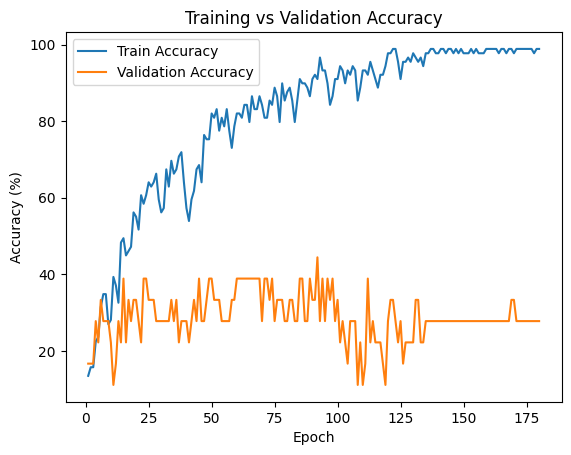

In [5]:
import matplotlib.pyplot as plt

# find common valid length
common_len = min(len(train_acc), len(val_acc))

epochs_acc = range(1, common_len + 1)

plt.figure()
plt.plot(epochs_acc, train_acc[:common_len], label="Train Accuracy")
plt.plot(epochs_acc, val_acc[:common_len], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()
